In [1]:
from __future__ import print_function
from __future__ import division
from __future__ import unicode_literals
import numpy as np
import deepchem as dc
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
2026-10-06 13:51:53.350839: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-06 13:51:53.538495: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-06 13:51:53.549179: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-10-06 13:51:53.54919

In [2]:
# Load ESOL with ECFP fingerprints
tasks, datasets, transformers = dc.molnet.load_delaney(
    featurizer="ECFP",
    split="random"
)

train_dataset, valid_dataset, test_dataset = datasets

X_train = train_dataset.X
y_train = train_dataset.y.ravel()

X_valid = valid_dataset.X
y_valid = valid_dataset.y.ravel()

X_test = test_dataset.X
y_test = test_dataset.y.ravel()

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=123
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

y_pred_test = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("Test RMSE:", rmse)
print("Test R²:", r2)





'split' is deprecated.  Use 'splitter' instead.
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:58] DEPRECATION WARNING: please use MorganGenerator
[13:51:5

(902, 1024)
(113, 1024)
(113, 1024)
Test RMSE: 0.48369405624726586
Test R²: 0.7407186782708948


In [40]:
# Load the datasets and predict the Solubility
generated_samples_class1 = pd.read_csv('gen_ESOL_class1_cont.csv',index_col=0)
generated_samples_class1_100 = pd.read_csv('final_generated_samples.csv')
generated_samples_class1_100 = generated_samples_class1_100.iloc[:,:-1]
real_high = pd.read_csv('High_Solubility.csv',index_col=0)
ESOL_dataset = pd.read_csv('esol_dataset.csv')
real_samples = ESOL_dataset.iloc[:,:-2]
real_solub = ESOL_dataset.iloc[:,-2:-1]
real_solub = real_solub.values
real_high_ECFPs = real_high.iloc[:,:-2].values
real_high_solub = real_high.iloc[:,-2:-1]
x_gen_class1 = generated_samples_class1.values
x_gen_class1_100 = generated_samples_class1_100.values
pred_class1 = xgb_model.predict(x_gen_class1)
pred_solub = xgb_model.predict(real_samples)
pred_class1_100 = xgb_model.predict(x_gen_class1_100)

In [41]:
predicted_esol = np.asarray(pred_class1_100).ravel()

# Remove NaN / infinite values
predicted_esol = predicted_esol[np.isfinite(predicted_esol)]

N = len(predicted_esol)

print("Number of predictions:", N)

# 2. Calculate statistical thresholds
# ------------------------------------------------------------

mean_esol = np.mean(predicted_esol)
median_esol = np.median(predicted_esol)
std_esol = np.std(predicted_esol)

min_esol = np.min(predicted_esol)
max_esol = np.max(predicted_esol)

# Percentile thresholds
threshold_90 = np.percentile(real_solub, 90)
threshold_99 = np.percentile(real_solub, 99)

# 3. Calculate percentages above thresholds
# ------------------------------------------------------------

n_above_90 = np.sum(predicted_esol >= threshold_90)
n_above_99 = np.sum(predicted_esol >= threshold_99)

percent_above_90 = 100 * n_above_90 / N
percent_above_99 = 100 * n_above_99 / N

# 4. Create KPI evaluation table
# ------------------------------------------------------------

kpi_results = pd.DataFrame({
    "KPI": [
        "Number of predictions",
        "Mean ESOL",
        "Median ESOL",
        "Standard deviation",
        "Minimum ESOL",
        "Maximum ESOL",
        "90th percentile threshold",
        "99th percentile threshold",
        "Number >= 90th percentile",
        "Percentage >= 99th percentile",
        "Number >= 90th percentile",
        "Percentage >= 99th percentile"
    ],

    "Value": [
        N,
        mean_esol,
        median_esol,
        std_esol,
        min_esol,
        max_esol,
        threshold_90,
        threshold_99,
        n_above_90,
        percent_above_90,
        n_above_99,
        percent_above_99
    ]
})


# ------------------------------------------------------------
# 5. Display KPI matrix
# ------------------------------------------------------------

print("\n==============================================")
print("             ESOL KPI EVALUATION")
print("==============================================")

display(kpi_results)


# ------------------------------------------------------------
# 6. Print the important values clearly
# ------------------------------------------------------------

print("\nMean ESOL:", mean_esol)
print("90th percentile threshold:", threshold_90)
print("99th percentile threshold:", threshold_99)
print(
    "Percentage >= 90th percentile:",
    f"{percent_above_90:.2f}%"
)

print(
    "Percentage >= 99th percentile:",
    f"{percent_above_99:.2f}%"
)


Number of predictions: 1000

             ESOL KPI EVALUATION


,KPI,Value
0,Number of predictions,1000.000000
1,Mean ESOL,2.481618
2,Median ESOL,2.502220
3,Standard deviation,0.263027
4,Minimum ESOL,1.521269
5,Maximum ESOL,3.216976
6,90th percentile threshold,1.222110
7,99th percentile threshold,1.949966
8,Number >= 90th percentile,1000.000000
9,Percentage >= 99th percentile,100.000000



Mean ESOL: 2.4816184
90th percentile threshold: 1.2221098535925794
99th percentile threshold: 1.949965770184762
Percentage >= 90th percentile: 100.00%
Percentage >= 99th percentile: 97.80%


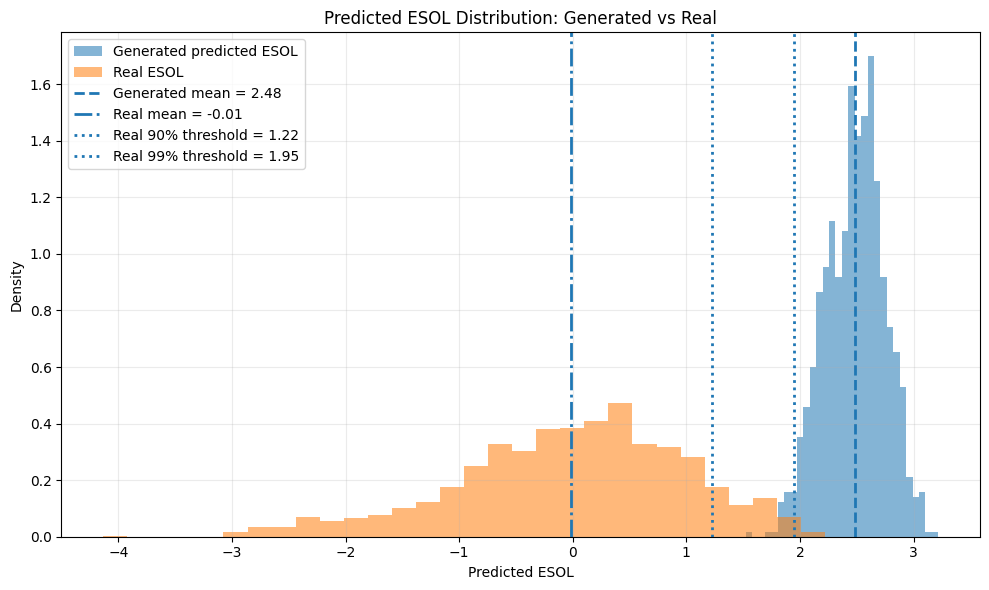

In [42]:
# 4. SAME HISTOGRAM: Generated vs Real predicted ESOL
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    predicted_esol,
    bins=30,
    alpha=0.55,
    label="Generated predicted ESOL",
    density=True
)

plt.hist(
    real_solub,
    bins=30,
    alpha=0.55,
    label="Real ESOL",
    density=True
)

# Mean of generated distribution
plt.axvline(
    predicted_esol.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Generated mean = {predicted_esol.mean():.2f}"
)

# Mean of real distribution
plt.axvline(
    real_solub.mean(),
    linestyle="-.",
    linewidth=2,
    label=f"Real mean = {real_solub.mean():.2f}"
)

# 90% and 99% thresholds calculated from REAL data
plt.axvline(
    threshold_90,
    linestyle=":",
    linewidth=2,
    label=f"Real 90% threshold = {threshold_90:.2f}"
)

plt.axvline(
    threshold_99,
    linestyle=":",
    linewidth=2,
    label=f"Real 99% threshold = {threshold_99:.2f}"
)

plt.xlabel("Predicted ESOL")
plt.ylabel("Density")
plt.title("Predicted ESOL Distribution: Generated vs Real")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# Compare generated and real samples

In [43]:
def compare_binary_bit_means(
    X_real,
    X_generated,
    feature_names=None,
    top_n=20,
    sort_by="abs_change",
    figsize=(10, 7)
):
    """
    Compare mean/prevalence of binary ECFP bits between
    real molecules and generated molecules.

    For binary features:
        mean(bit) = P(bit == 1)

    Parameters
    ----------
    X_real : array-like
        Real binary ECFP matrix, shape (n_real, n_bits).

    X_generated : array-like
        Generated binary ECFP matrix, shape (n_generated, n_bits).

    feature_names : list, optional
        Names of the ECFP bits.

    top_n : int
        Number of most changed bits to display.

    sort_by : str
        "abs_change" -> largest absolute changes
        "positive"   -> bits increased the most
        "negative"   -> bits decreased the most

    figsize : tuple
        Figure size.

    Returns
    -------
    results : pd.DataFrame
        Statistics for every bit.
    """

    X_real = np.asarray(X_real)
    X_generated = np.asarray(X_generated)

    # Check dimensions
    if X_real.shape[1] != X_generated.shape[1]:
        raise ValueError(
            "Real and generated data must have the same number of bits."
        )

    n_bits = X_real.shape[1]

    if feature_names is None:
        feature_names = [f"Bit_{i}" for i in range(n_bits)]

    # ---------------------------------------------------------
    # Mean of binary bits = frequency of bit being present
    # ---------------------------------------------------------

    real_mean = X_real.mean(axis=0)
    generated_mean = X_generated.mean(axis=0)

    # Difference
    change = generated_mean - real_mean

    # Absolute difference
    abs_change = np.abs(change)

    # ---------------------------------------------------------
    # Create results table
    # ---------------------------------------------------------

    results = pd.DataFrame({
        "bit": feature_names,
        "real_mean": real_mean,
        "generated_mean": generated_mean,
        "change": change,
        "abs_change": abs_change
    })

    # ---------------------------------------------------------
    # Sort
    # ---------------------------------------------------------

    if sort_by == "abs_change":
        results = results.sort_values(
            "abs_change",
            ascending=False
        )

    elif sort_by == "positive":
        results = results.sort_values(
            "change",
            ascending=False
        )

    elif sort_by == "negative":
        results = results.sort_values(
            "change",
            ascending=True
        )

    else:
        raise ValueError(
            "sort_by must be 'abs_change', 'positive', or 'negative'"
        )

    # Top features
    top = results.head(top_n).copy()

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    plt.figure(figsize=figsize)

    colors = [
        "steelblue" if x > 0 else "indianred"
        for x in top["change"]
    ]

    plt.barh(
        np.arange(len(top)),
        top["change"],
        color=colors
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1
    )

    plt.yticks(
        np.arange(len(top)),
        top["bit"]
    )

    plt.xlabel(
        "Change in bit mean\n"
        "(generated high-solubility − real)"
    )

    plt.ylabel("ECFP bit")

    plt.title(
        "Binary feature changes after high-solubility conditioning"
    )

    # Put largest feature at top
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

    return results

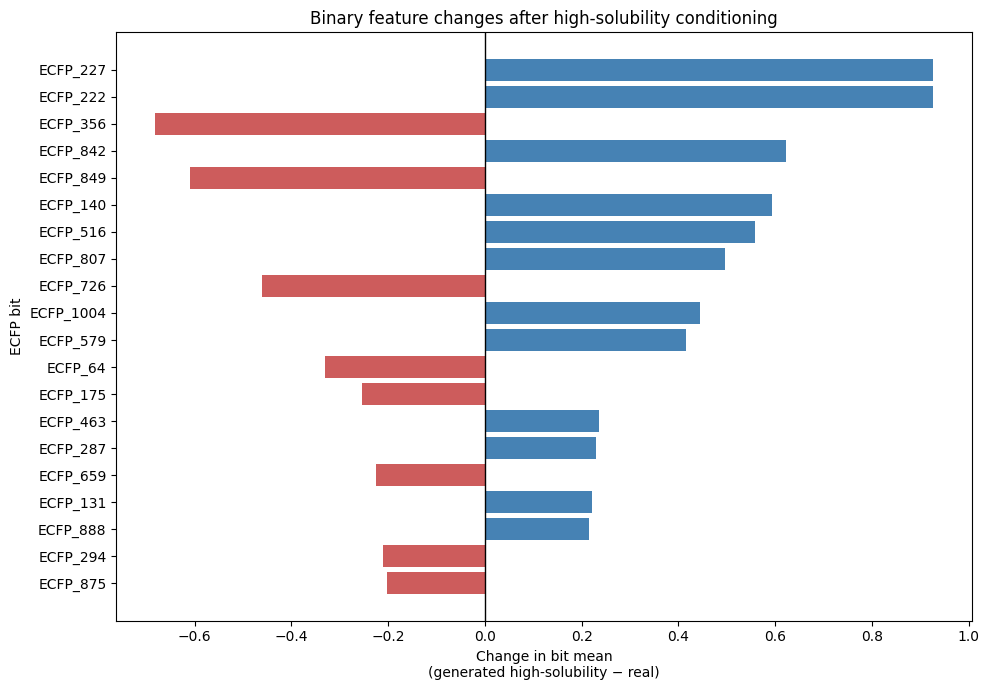

In [44]:
column_names = real_samples.columns
bit_results = compare_binary_bit_means(
    X_real= real_samples,
    X_generated= x_gen_class1_100,
    feature_names=column_names,
    top_n=20
)

# Scatter plot

In [45]:
def plot_real_vs_generated_bit_means(
    results,
    figsize=(8, 8),
    highlight_top_n=10
):
    """
    Plot real bit means against generated bit means.
    """

    plt.figure(figsize=figsize)

    plt.scatter(
        results["real_mean"],
        results["generated_mean"],
        alpha=0.35,
        s=20
    )

    # Diagonal = no distributional change
    lims = [
        0,
        max(
            results["real_mean"].max(),
            results["generated_mean"].max()
        )
    ]

    plt.plot(
        lims,
        lims,
        "--",
        color="black",
        linewidth=1
    )

    # Highlight largest changes
    top = results.head(highlight_top_n)

    plt.scatter(
        top["real_mean"],
        top["generated_mean"],
        s=45,
        color="red",
        label=f"Top {highlight_top_n} changes"
    )

    # Label the important bits
    for _, row in top.iterrows():

        plt.annotate(
            str(row["bit"]),
            (
                row["real_mean"],
                row["generated_mean"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    plt.xlabel("Mean bit value — real molecules")
    plt.ylabel("Mean bit value — generated molecules")

    plt.title(
        "Real vs generated ECFP bit distributions"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

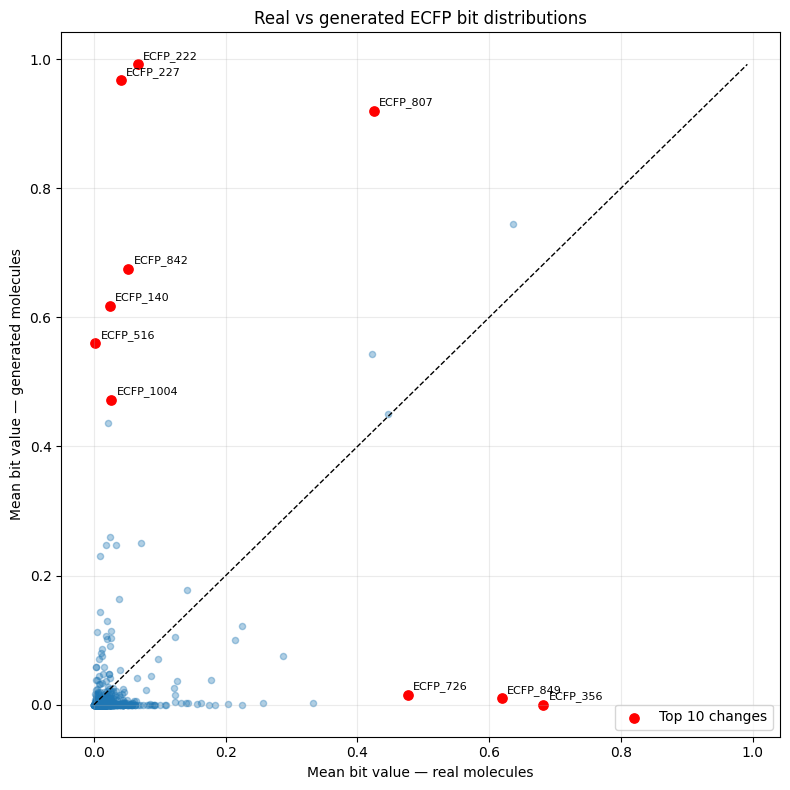

In [46]:
plot_real_vs_generated_bit_means(
    bit_results,
    highlight_top_n=10
)